In [1]:
import pandas as pd 
import numpy as np

df_values = pd.read_csv("/kaggle/input/datasets/alexandrabln7/uni-dataset/train_samples.csv", header=None)
df_labels = pd.read_csv("/kaggle/input/datasets/alexandrabln7/uni-dataset/train_labels.csv", header=None)

In [2]:
df_labels.head()

,0
0,8.0
1,4.0
2,5.0
3,7.0
4,2.0


In [3]:
df_values.head()

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,0.120390,0.323718,0.000034,0.000029,0.492832,0.047880,0.931094,0.000000,0.018634,0.045943,...,0.000078,0.991924,0.000000,0.002282,0.984992,0.991536,0.000133,0.936120,0.351642,0.126884
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000342,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.174209,0.435465,0.737319,0.000000,0.559430,0.000000,0.396687,0.666864,0.561351,...,0.917756,0.989727,0.027454,0.778100,0.025024,0.564567,0.521900,0.873315,0.547711,0.534635
3,0.676849,0.837333,0.000055,0.000210,0.000221,0.624539,0.098614,0.756432,0.736644,0.785873,...,0.039870,0.021393,0.700645,0.108689,0.114870,0.834326,0.000106,0.936926,0.000054,0.709673
4,0.762416,0.000283,0.000398,0.866443,0.000000,0.959211,0.000090,0.132567,0.315940,0.633218,...,0.777510,0.236998,0.420625,0.992142,0.065235,0.000037,0.984635,0.796889,0.800577,0.000919


In [4]:
print(df_values.shape)
print(df_labels.shape)

(784, 1000)
(1000, 1)


* numarul de linii din df_values nu corespunde cu cel din df_labels asa ca facem transpusa
* np.ravel() transforma df_labels intr-un vector 1D

In [5]:
X = df_values.T.values
y = df_labels.values.ravel()

* facem -1 deoarece clasele incep de la 1 iar sparse_categorical_crossentropy asteapta 0-based integer labels

In [6]:
y = (y - 1).astype(int)
print('Classes:', np.unique(y))
print('Num classes:', len(np.unique(y)))

Classes: [0 1 2 3 4 5 6 7 8 9]
Num classes: 10


* early stopping opreste training-ul cand validation loss nu mai scade (monitor='val_loss')
* patience=5 inseamna ca mai asteapta inca 5 epochs in care val_loss nu scade inainte de a se opri
* restore_best_weights = True -> se intoarce la epoch-ul cu cel mai mic val_loss

In [7]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

2026-04-17 13:09:05.899283: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776431346.145967      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776431346.217517      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776431346.759513      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776431346.759559      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776431346.759562      16 computation_placer.cc:177] computation placer alr

In [8]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA

# StratifiedKFold are grija ca fiecare fold are aceeasi distributie a claselor ca si tot dataset-ul, shuffle=True amesteca split-urile
# Pentru fiecare fold (10): 
 1. Impartim datele in train/test folosing indicii fold-ului curent
 2. PCA pe datele de training (de la 784 la 80 features), el pastreaza cele mai importante features, pe datele de train invata si aplica transformarea iar pe test doar transforma pentru a nu avea data leakage
 3. Definim un MLP folosind tensorflow.keras unde avem :
    * Input layer care primeste dimensiunea componentelor ramase dupa PCA

    * 3 straturi Dense cu 256 - 128 - 32 neuroni, primul invata din pattern-uri, al doilea vede caracteristici mai                                                                abstracte, iar ultimul pregateste pentru output

    *  Functia de activare ReLu (pastreaza valori pozitive si taie negative)

    *  BatchNormalization() normalizeaza valorile pt stabilitate
   
    *  Dropout opreste aleatoriu din neuroni la fiecare pas pentru a previne overfitting, am folosit 0.4 apoi 0.3 adica                                                                40% si 30% din neuroni

    *  Output layer Dense cu 10 neuroni pentru 10 clase, cu functia de activare softmax care transforma output-ul in                                                                   probabilitati cu suma totala 1, iar clasa cu cea mai mare probabilitate este rezultatul (bun pentru multiclass)
    
  5. Train cu optimizarea Adam + sparse categorical crossentropy pana la 150 de epochs folosind 10% din date pentru validare, impreuna cu early stopping
  6. Record:
     * epoch-ul unde s-a oprit trainingul pentru a afla cea mai buna valoare
     * acuratetea
     * confusion matrix


In [9]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

accuracies = []
conf_matrices = []
best_epoch_list = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    
    X_train_raw, X_test_raw = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    pca = PCA(n_components=80, random_state=42)
    X_train = pca.fit_transform(X_train_raw)
    X_test  = pca.transform(X_test_raw)

    n_components = X_train.shape[1]

    model = Sequential([
        Input(shape=(n_components,)),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train, y_train,
        epochs=150,
        batch_size=16,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )

    best_epoch_list.append(len(history.history['loss']))
    
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    conf_matrices.append(confusion_matrix(y_test, y_pred))

    print(f"  Accuracy: {acc:.4f} | Stopped at epoch: {best_epoch_list[-1]}")

2026-04-17 13:09:36.202858: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


  Accuracy: 0.9100 | Stopped at epoch: 19
  Accuracy: 0.9700 | Stopped at epoch: 18
  Accuracy: 0.9600 | Stopped at epoch: 14
  Accuracy: 0.9600 | Stopped at epoch: 14
  Accuracy: 0.9000 | Stopped at epoch: 13
  Accuracy: 0.8800 | Stopped at epoch: 22
  Accuracy: 0.9500 | Stopped at epoch: 15
  Accuracy: 0.9100 | Stopped at epoch: 14
  Accuracy: 0.9100 | Stopped at epoch: 20
  Accuracy: 0.9400 | Stopped at epoch: 20


* calculam mean si std of accuracy pentru toate cele 10 fold-uri
* construim intervalul de incredere de 90% folosind aproximarea normala: CI = mean ± 1.645 * (std / sqrt(n_folds))

In [10]:
mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)

ci_lower = mean_acc - 1.645 * (std_acc / np.sqrt(10))
ci_upper = mean_acc + 1.645 * (std_acc / np.sqrt(10))

print(f"Mean Accuracy : {mean_acc:.4f}")
print(f"Std Accuracy  : {std_acc:.4f}")
print(f"90% CI        : ({ci_lower:.4f}, {ci_upper:.4f})")
print(f"Avg stop epoch: {np.mean(best_epoch_list):.1f}")

Mean Accuracy : 0.9290
Std Accuracy  : 0.0291
90% CI        : (0.9138, 0.9442)
Avg stop epoch: 16.9


* Facem confusion matrix folosind un heatmap pentru fiecare fold
* Valorile de pe diagonala sunt predictiile corecte, iar celelalte sunt erori

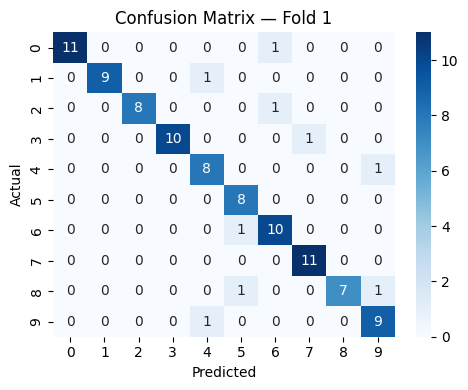

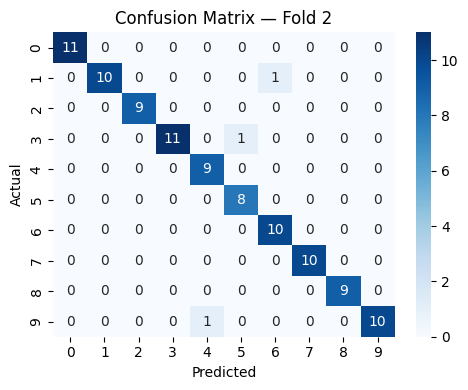

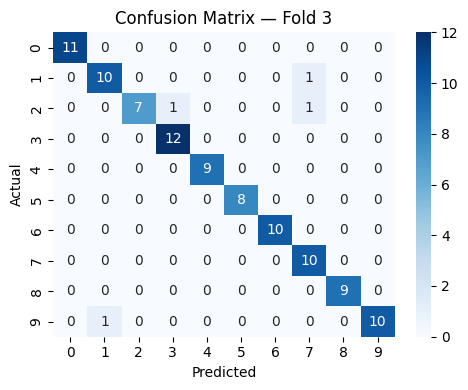

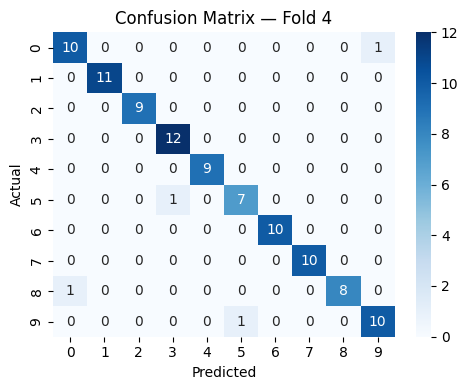

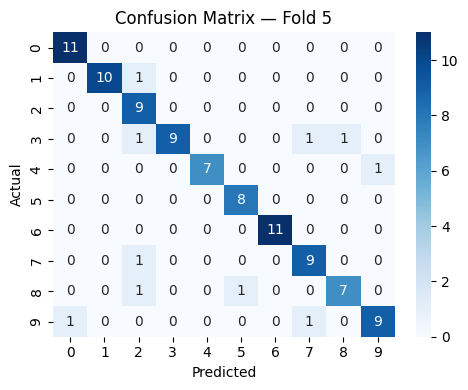

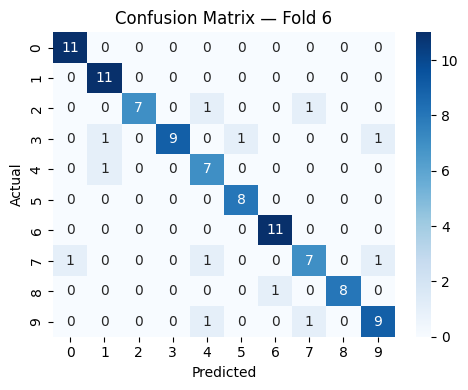

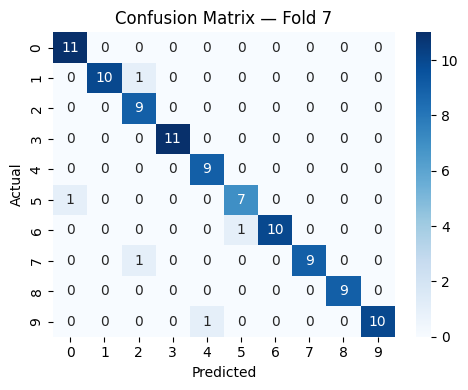

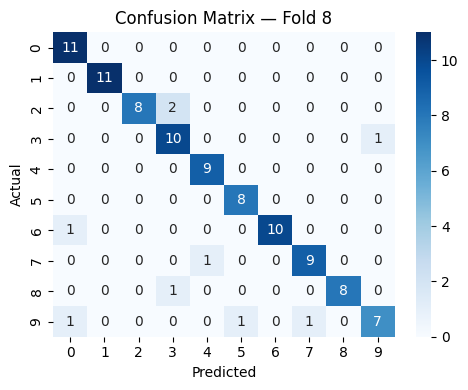

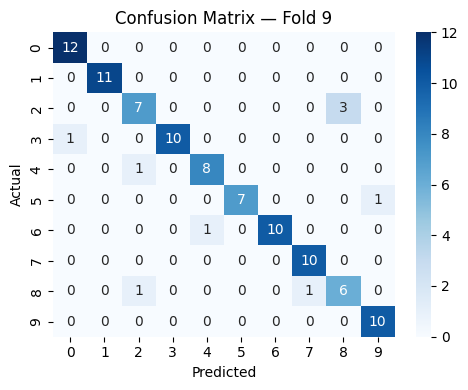

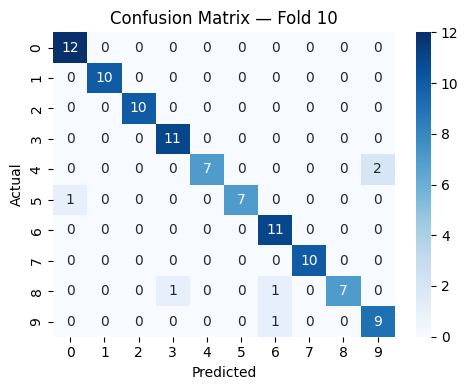

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

for i, cm in enumerate(conf_matrices):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix — Fold {i + 1}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

In [12]:
df_test = pd.read_csv("/kaggle/input/datasets/alexandrabln7/uni-dataset/test_samples.csv", header=None)
X_test_final = df_test.T.values
X_test_final.shape

(5000, 784)

In [13]:
print(best_epoch_list)

[19, 18, 14, 14, 13, 22, 15, 14, 20, 20]


* facem mediana (valoarea de mijloc) listei de epochs
* pentru modelul final mediana este mai buna pentru outliers decat media (mean)

In [14]:
avg_epochs = int(np.median(best_epoch_list))

* repetam invatarea si transformarea PCA pentru toate datele de antrenare (1000 samples) 

In [15]:
pca_final = PCA(n_components=80, random_state=42)
X_full = pca_final.fit_transform(X)
print(f"Final PCA components: {pca_final.n_components_}")

Final PCA components: 80


# Construim si antrenam modelul final folosind toate datele de testare
* arhitectura este identica cu cea de mai sus
* folosim avg_epochs, iar spre deosebire de modelul anterior nu mai folosim validation split si early stopping deoarece antrenam modelul pe tot setul de date pe un numar fix de epoci 

In [16]:
final_model = Sequential([
        Input(shape=(n_components,)),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(10, activation='softmax')
    ])

final_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

final_model.fit(
    X_full, y,
    epochs=avg_epochs,
    batch_size=16,
    verbose=1
)

Epoch 1/16
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3283 - loss: 2.0813
Epoch 2/16
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7317 - loss: 0.8369
Epoch 3/16
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8432 - loss: 0.6056
Epoch 4/16
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8656 - loss: 0.5095
Epoch 5/16
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8905 - loss: 0.3806
Epoch 6/16
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8930 - loss: 0.3121
Epoch 7/16
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9337 - loss: 0.2449
Epoch 8/16
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9195 - loss: 0.2494
Epoch 9/16
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9381 - loss: 0.1866
Epoch 10/16
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9525 - loss: 0.1437
Epoch 11/16
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9489 - loss: 0.1629
Epoch 12/16
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9715 - lo

In [17]:
X_test_pca = pca_final.transform(X_test_final)

* rulam modelul final pe datele de test transformate cu PCA
* np.argmax() returneaza indexul clasei cu cea mai mare probabilitate
* adaugam + 1 pentru a reveni la valorile de inceput (1-10)

In [18]:
pred_probs = final_model.predict(X_test_pca, verbose=0)
preds = np.argmax(pred_probs, axis=1) + 1

In [19]:
submission = pd.DataFrame({
    "Id": np.arange(1, len(preds) + 1),
    "Prediction": preds
})

submission.to_csv("submission.csv", index=False)
submission.head(10)

,Id,Prediction
0,1,6
1,2,2
2,3,2
3,4,4
4,5,7
5,6,3
6,7,7
7,8,4
8,9,4
9,10,2
